# Exercise: Multilateration and Measurement Noise

In this exercise you will implement 2D multilateration using the **Least Squares** method and investigate how distance measurement errors affect the estimated position.

## Scenario

Four WiFi access points (anchors) are installed at known positions in a room.  
A mobile device measures the RSSI to each anchor and converts it to a distance estimate.  
Your goal: compute the position of the mobile device from those distance estimates.

```
A3 (1,6) -------- A4 (6,6)
  |                  |
  |       M (?)      |
  |                  |
A1 (1,1) -------- A2 (6,1)
```

## Learning Goals
- Translate the multilateration equations from the lecture into Python code
- Understand the effect of noisy distance measurements on positioning accuracy
- Use `numpy.linalg.lstsq` to solve an overdetermined linear system

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

---
## Task 1 – Setup

Define the anchor positions and the true position of the mobile node.

In [2]:
# Anchor positions (x, y) in meters
anchors = np.array([
    [1.0, 1.0],   # A1
    [6.0, 1.0],   # A2
    [1.0, 6.0],   # A3
    [6.0, 6.0],   # A4
])

# True position of the mobile node M
M_true = np.array([3.5, 4.0])

print("Anchors:")
for i, a in enumerate(anchors):
    print(f"  A{i+1} = {a}")
print(f"True position M = {M_true}")

Anchors:
  A1 = [1. 1.]
  A2 = [6. 1.]
  A3 = [1. 6.]
  A4 = [6. 6.]
True position M = [3.5 4. ]


---
## Task 2 – True Distances

Compute the **true** Euclidean distances from each anchor to the mobile node M.

$$d_i = \|\mathbf{M} - \mathbf{A}_i\| = \sqrt{(x - x_i)^2 + (y - y_i)^2}$$

**TODO:** Fill in the distance calculation below.

In [3]:
true_distances = np.linalg.norm(anchors - M_true, axis=1)

# --- do not modify below ---
print("True distances:")
for i, d in enumerate(true_distances):
    print(f"  d{i+1} = {d:.4f} m")

True distances:
  d1 = 3.9051 m
  d2 = 3.9051 m
  d3 = 3.2016 m
  d4 = 3.2016 m


---
## Task 3 – Implement Multilateration (Least Squares)

From the lecture, the multilateration system can be linearised by subtracting the equation of anchor 1 from all others:

$$d_1^2 - d_i^2 = -2(x_i - x_1)\,x - 2(y_i - y_1)\,y + (x_i^2 - x_1^2) + (y_i^2 - y_1^2)$$

Rearranged into the form $\mathbf{A}\mathbf{x} = \mathbf{b}$:

$$\mathbf{A} =
\begin{bmatrix}
x_2 - x_1 & y_2 - y_1 \\
x_3 - x_1 & y_3 - y_1 \\
\vdots & \vdots
\end{bmatrix},
\qquad
\mathbf{b} = \frac{1}{2}
\begin{bmatrix}
d_1^2 - d_2^2 + x_2^2 - x_1^2 + y_2^2 - y_1^2 \\
d_1^2 - d_3^2 + x_3^2 - x_1^2 + y_3^2 - y_1^2 \\
\vdots
\end{bmatrix}$$

**TODO:** Implement the function `multilaterate(anchors, distances)` that returns the estimated 2D position.

In [4]:
def multilaterate(anchors, distances):
    """
    Estimate 2D position using least-squares multilateration.

    Parameters
    ----------
    anchors   : (N, 2) array of anchor coordinates
    distances : (N,)   array of measured distances to each anchor

    Returns
    -------
    pos : (2,) estimated position [x, y]
    """
    x1, y1 = anchors[0]
    d1     = distances[0]

    A = []
    b = []

    for i in range(1, len(anchors)):
        xi, yi = anchors[i]
        di     = distances[i]

        A.append([xi - x1, yi - y1])
        b.append(0.5 * (d1**2 - di**2 + xi**2 - x1**2 + yi**2 - y1**2))

    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)

    pos, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    return pos


# --- test with exact distances ---
M_est = multilaterate(anchors, true_distances)
print(f"True position :  {M_true}")
print(f"Estimated pos :  {M_est}")
print(f"Error         :  {np.linalg.norm(M_est - M_true):.6f} m")

True position :  [3.5 4. ]
Estimated pos :  [3.5 4. ]
Error         :  0.000000 m


---
## Task 4 – Add Measurement Noise

In practice, RSSI-based distance estimates are noisy.  
Model this by adding zero-mean Gaussian noise with standard deviation $\sigma$ to each distance:

$$\tilde{d}_i = d_i + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0,\, \sigma^2)$$

**TODO:** Complete the cell below, then try different values of `sigma` (e.g. 0.1, 0.5, 1.0, 2.0).  
Observe: *how does the estimated position change?*

In [5]:
sigma = 0.5   # <-- change this value and re-run

noisy_distances = true_distances + np.random.normal(0, sigma, size=len(true_distances))

M_est_noisy = multilaterate(anchors, noisy_distances)

print(f"sigma = {sigma} m")
print(f"Noisy distances : {noisy_distances.round(3)}")
print(f"True position   : {M_true}")
print(f"Estimated pos   : {M_est_noisy.round(4)}")
print(f"Position error  : {np.linalg.norm(M_est_noisy - M_true):.4f} m")

sigma = 0.5 m
Noisy distances : [3.617 5.376 2.696 3.006]
True position   : [3.5 4. ]
Estimated pos   : [2.3865 4.5497]
Position error  : 1.2418 m


---
## Task 5 – Visualisation

Plot the following in a single figure:
- anchor positions (blue squares)
- true position M (green star)
- estimated position with noise (red cross)
- dashed circles with radius = noisy distance around each anchor

**TODO:** Complete the plotting code.

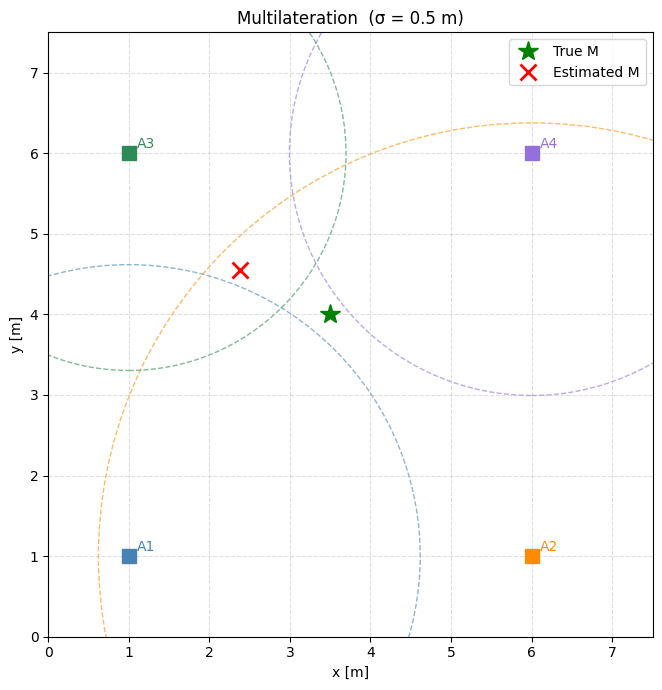

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, 7.5)
ax.set_ylim(0, 7.5)
ax.set_aspect('equal')
ax.set_title(f'Multilateration  (σ = {sigma} m)')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.grid(True, linestyle='--', alpha=0.4)

colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']

for i, (anchor, d) in enumerate(zip(anchors, noisy_distances)):
    circle = mpatches.Circle(anchor, d, fill=False, linestyle='--',
                             color=colors[i], alpha=0.6)
    ax.add_patch(circle)
    ax.plot(*anchor, 's', color=colors[i], markersize=10)
    ax.annotate(f'A{i+1}', anchor, textcoords='offset points',
                xytext=(6, 4), fontsize=10, color=colors[i])

ax.plot(*M_true, 'g*', markersize=15, label='True M')
ax.plot(*M_est_noisy, 'rx', markersize=12, markeredgewidth=2, label='Estimated M')

ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

---
## Task 6 – Statistical Analysis

A single noisy measurement does not tell the full story.  
Run multilateration **1000 times** for each noise level and record the position error.

**TODO:** Complete the simulation loop and the plot.

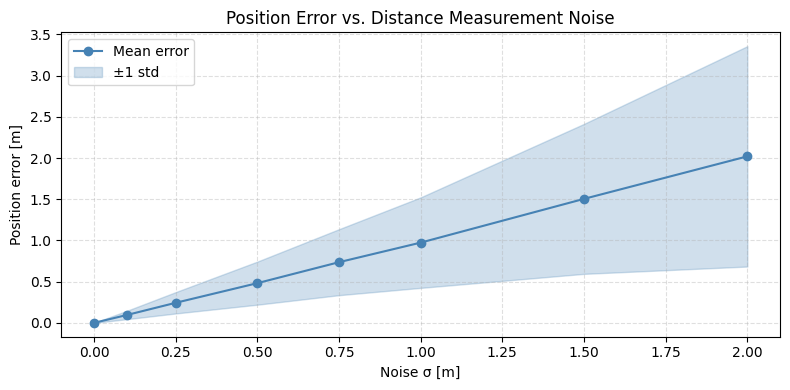

In [7]:
sigma_values = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
n_trials     = 1000

mean_errors = []
std_errors  = []

for sigma in sigma_values:
    errors = []
    for _ in range(n_trials):
        noisy_d = true_distances + np.random.normal(0, sigma, size=len(true_distances))
        M_est   = multilaterate(anchors, noisy_d)
        error   = np.linalg.norm(M_est - M_true)
        errors.append(error)

    mean_errors.append(np.mean(errors))
    std_errors.append(np.std(errors))

mean_errors = np.array(mean_errors)
std_errors  = np.array(std_errors)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sigma_values, mean_errors, 'o-', color='steelblue', label='Mean error')
ax.fill_between(sigma_values,
                mean_errors - std_errors,
                mean_errors + std_errors,
                alpha=0.25, color='steelblue', label='±1 std')
ax.set_xlabel('Noise σ [m]')
ax.set_ylabel('Position error [m]')
ax.set_title('Position Error vs. Distance Measurement Noise')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Bonus – More Anchors, Less Error?

The least-squares method benefits from **redundant measurements**.  

**Task:** Repeat the statistical analysis from Task 6, but this time compare
- 3 anchors (e.g. A1, A2, A3 only)
- 4 anchors (default)
- 6 anchors (add two more at e.g. `[3.5, 0.5]` and `[3.5, 6.5]`)

Plot all three curves in the same figure.  
**Discussion:** How does the number of anchors affect positioning accuracy?

*(No TODO skeleton – implement from scratch)*

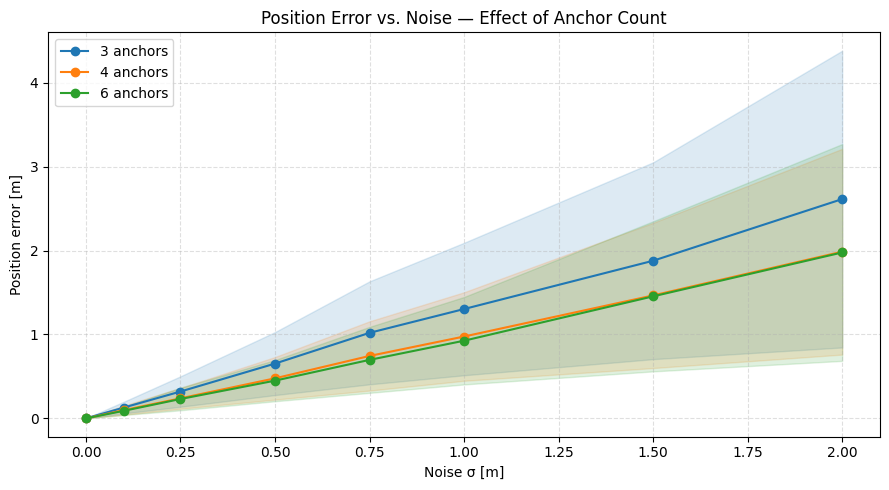

In [8]:
sigma_values = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
n_trials     = 1000

anchor_configs = {
    '3 anchors': anchors[:3],
    '4 anchors': anchors,
    '6 anchors': np.vstack([anchors, [[3.5, 0.5], [3.5, 6.5]]]),
}

fig, ax = plt.subplots(figsize=(9, 5))

for label, anch in anchor_configs.items():
    true_d = np.linalg.norm(anch - M_true, axis=1)
    mean_errors = []
    std_errors  = []

    for sigma in sigma_values:
        errors = []
        for _ in range(n_trials):
            noisy_d = true_d + np.random.normal(0, sigma, size=len(true_d))
            M_est   = multilaterate(anch, noisy_d)
            errors.append(np.linalg.norm(M_est - M_true))
        mean_errors.append(np.mean(errors))
        std_errors.append(np.std(errors))

    mean_errors = np.array(mean_errors)
    std_errors  = np.array(std_errors)

    line, = ax.plot(sigma_values, mean_errors, 'o-', label=label)
    ax.fill_between(sigma_values,
                    mean_errors - std_errors,
                    mean_errors + std_errors,
                    alpha=0.15, color=line.get_color())

ax.set_xlabel('Noise σ [m]')
ax.set_ylabel('Position error [m]')
ax.set_title('Position Error vs. Noise — Effect of Anchor Count')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Questions for Reflection

Answer the following questions in the cell below (or on paper):

1. With **exact** distances (σ = 0), does the multilateration give the exact position? Why?
2. What happens to the estimated position when the noise is very large (σ > 2 m)?
3. The noise model used here is additive Gaussian. Is that realistic for RSSI-based distance estimation? What would be a more accurate model?
4. In what direction does the position error tend to shift when one anchor has a much larger error than the others?

**Your answers:**

1. Yes, with exact distances (σ = 0) multilateration returns the exact position. With 4 anchors the linearised system has 3 equations for 2 unknowns. Because the equations are perfectly consistent (no noise), the least-squares residual is zero and `lstsq` recovers the true position exactly.

2. At very large noise (σ > 2 m) the noisy distances lose all relationship to the geometry. The estimated position can land far outside the anchor rectangle, jump erratically between runs, and the mean error grows roughly linearly with σ. The least-squares solver has no way to detect or reject outlier measurements, so a single badly corrupted distance drags the estimate significantly off course.

3. Additive Gaussian noise on distance is not realistic for RSSI-based estimation. RSSI fluctuations are approximately Gaussian in the **dBm** domain (log scale), but the path-loss inversion is an exponential: `d = 10^(…/20)`. This makes the resulting distance errors **multiplicative and right-skewed** (log-normal), not symmetric. A more accurate model is Gaussian noise added to RSSI (as implemented in Task 7), or a full log-normal shadowing model that also accounts for multipath fading and obstacles.

4. The estimated position shifts **away from** an anchor whose measured distance is over-estimated (noise pushed it too large), and **toward** an anchor whose distance is under-estimated. Because least-squares minimises the sum of squared residuals equally across all equations, the anchor with the largest error contributes the most to the objective and pulls the solution disproportionately in its direction.

---
## Task 7 – From RSSI to Distance: How Bad Is It Really?

So far we assumed that distances are known directly.  
In practice, RSSI is measured and **converted** to a distance using the inverse path loss model from the lecture:

$$\text{RSSI}(d,f) = -20\log_{10}(d) - 20\log_{10}(f) + K$$

$$\Rightarrow\quad d = 10^{\,\dfrac{K - 20\log_{10}(f) - \text{RSSI}}{20}}$$

with:
- $K$: calibration constant (transmit power + antenna gain), e.g. $K = 20$
- $f$: frequency in MHz — WiFi 2.4 GHz → $f = 2400$
- RSSI in dBm

Indoor RSSI measurements typically fluctuate by **±5–10 dBm** even at a constant distance.

**TODO:**
1. Implement `rssi_from_distance(d, f, K)` using the path loss formula above
2. Implement `distance_from_rssi(rssi, f, K)` as the inverse
3. Convert `true_distances` → RSSI values → add Gaussian noise (σ_RSSI = 6 dBm) → convert back to distances
4. Run multilateration with those distances
5. Repeat 200 times and plot the scatter of estimated positions
6. Compare the spread to the σ = 0.5 m direct-noise case from Task 4

RSSI at 1 m : -47.60422483423211
Round-trip  : 4.999999999999999


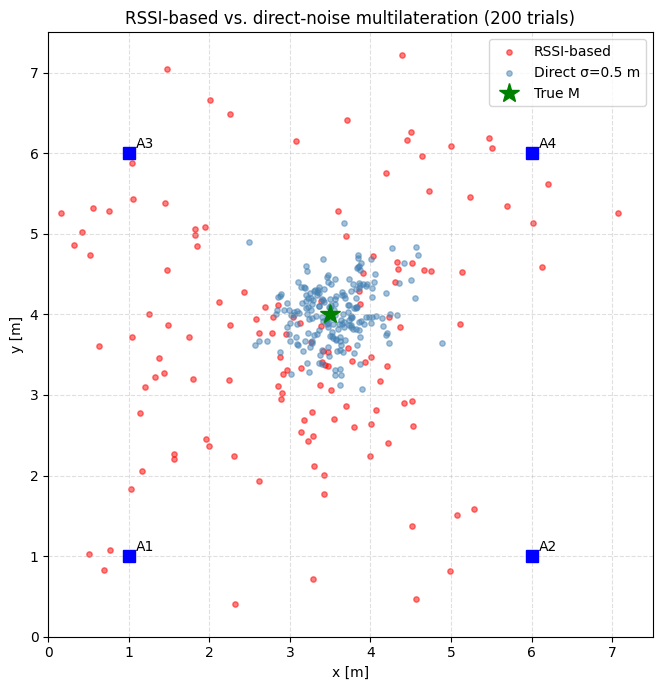

Mean error RSSI-based  : 4.932 m
Mean error direct σ=0.5: 0.475 m


In [9]:
F_MHZ   = 2400   # WiFi 2.4 GHz
K       = 20     # calibration constant
SIGMA_RSSI = 6   # realistic indoor RSSI noise in dBm


def rssi_from_distance(d, f=F_MHZ, K=K):
    """Convert distance [m] to RSSI [dBm] using the path loss model."""
    return -20 * np.log10(d) - 20 * np.log10(f) + K


def distance_from_rssi(rssi, f=F_MHZ, K=K):
    """Inverse path loss model: convert RSSI [dBm] to distance [m]."""
    return 10 ** ((K - 20 * np.log10(f) - rssi) / 20)


# --- quick sanity check ---
print("RSSI at 1 m :", rssi_from_distance(1.0))
print("Round-trip  :", distance_from_rssi(rssi_from_distance(5.0)))


# --- scatter plot: 200 RSSI-based estimates vs 200 direct-noise estimates ---
rng      = np.random.default_rng(7)
n_trials = 200

rssi_estimates   = []
direct_estimates = []

true_rssi = rssi_from_distance(true_distances)

for _ in range(n_trials):
    noisy_rssi     = true_rssi + rng.normal(0, SIGMA_RSSI, size=len(true_rssi))
    dist_from_rssi = distance_from_rssi(noisy_rssi)
    rssi_estimates.append(multilaterate(anchors, dist_from_rssi))

    noisy_d = true_distances + rng.normal(0, 0.5, size=len(true_distances))
    direct_estimates.append(multilaterate(anchors, noisy_d))

rssi_estimates   = np.array(rssi_estimates)
direct_estimates = np.array(direct_estimates)

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, 7.5)
ax.set_ylim(0, 7.5)
ax.set_aspect('equal')
ax.set_title('RSSI-based vs. direct-noise multilateration (200 trials)')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.grid(True, linestyle='--', alpha=0.4)

for i, a in enumerate(anchors):
    ax.plot(*a, 'bs', markersize=9)
    ax.annotate(f'A{i+1}', a, textcoords='offset points', xytext=(5, 4))

ax.scatter(rssi_estimates[:, 0], rssi_estimates[:, 1],
           color='red', s=15, alpha=0.5, label='RSSI-based')
ax.scatter(direct_estimates[:, 0], direct_estimates[:, 1],
           color='steelblue', s=15, alpha=0.5, label='Direct σ=0.5 m')
ax.plot(*M_true, 'g*', markersize=15, label='True M')

ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean error RSSI-based  : {np.mean(np.linalg.norm(rssi_estimates - M_true, axis=1)):.3f} m")
print(f"Mean error direct σ=0.5: {np.mean(np.linalg.norm(direct_estimates - M_true, axis=1)):.3f} m")